In [9]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import yfinance as yf

# 1. Get the data into a DataFrame named 'df'
msft_data = yf.Ticker('MSFT')
df = msft_data.history(start='2020-01-01')

# Clean columns if needed (removes multi-index if present)
df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns

# Clean and view
df = df.dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1644.0,3.224576e+02,1.003623e+02,1.298655e+02,2.380773e+02,3.122166e+02,4.091445e+02,5.508301e+02
High,1644.0,3.255953e+02,1.007757e+02,1.332398e+02,2.411433e+02,3.151245e+02,4.116389e+02,5.510484e+02
Low,1644.0,3.191622e+02,9.970448e+01,1.256096e+02,2.363710e+02,3.087726e+02,4.046753e+02,5.373668e+02
Close,1644.0,3.225056e+02,1.002486e+02,1.283584e+02,2.392247e+02,3.127219e+02,4.084648e+02,5.386586e+02
Volume,1644.0,2.838366e+07,1.326756e+07,5.855900e+06,2.006522e+07,2.522970e+07,3.286818e+07,1.862016e+08
Dividends,1644.0,1.096107e-02,8.796849e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.100000e-01
Stock Splits,1644.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [ ]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# 3. Create Daily Returns column for the second test
df['Daily_Return'] = df['Close'].pct_change()

In [11]:
def check_stationarity(series):
    # Perform Augmented Dickey-Fuller test
    result = adfuller(series.dropna(), autolag='AIC')
    
    print("--- ADF Test Results ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if result[1] <= 0.05:
        print("\nConclusion: Reject the null hypothesis. The series is STATIONARY.")
    else:
        print("\nConclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.")

# 4. FIX: Pass the 'df' columns into the stationarity check
print("Testing Raw Close Price:")
check_stationarity(df['Close'])

print("\nTesting Daily Returns:")
check_stationarity(df['Daily_Return'])

Testing Raw Close Price:
--- ADF Test Results ---
ADF Statistic: -1.6236
p-value: 0.4708
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677

Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.

Testing Daily Returns:
--- ADF Test Results ---
ADF Statistic: -12.9968
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677

Conclusion: Reject the null hypothesis. The series is STATIONARY.


[*********************100%***********************]  1 of 1 completed


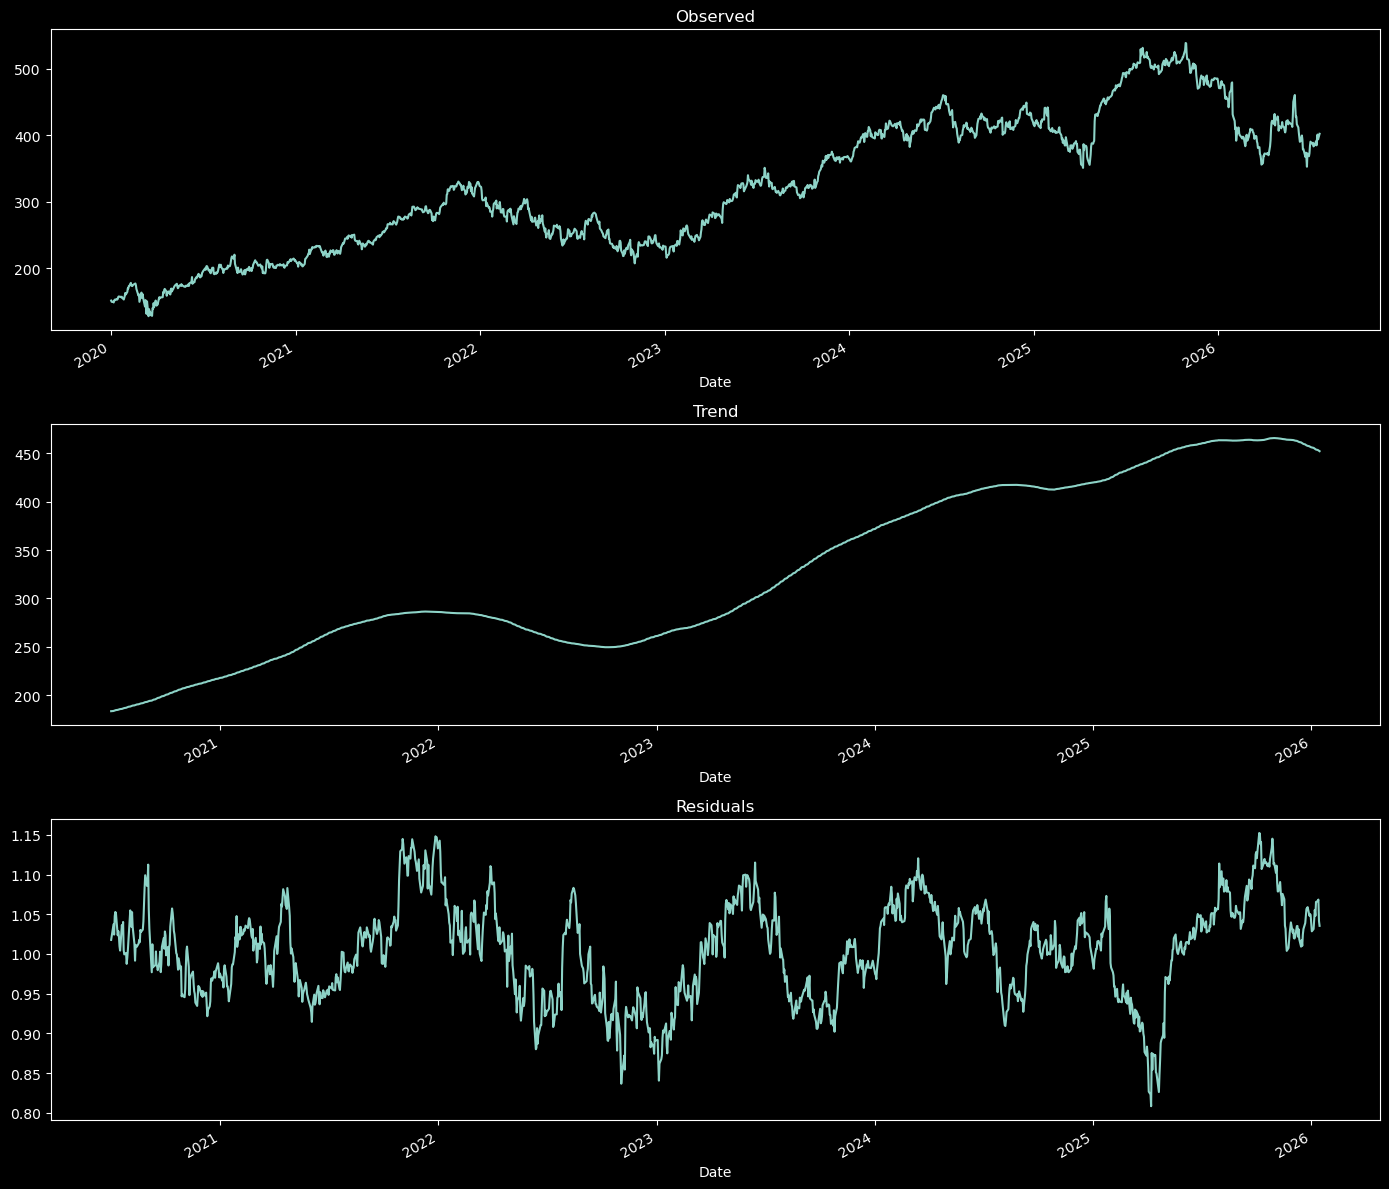

Results of Dickey-Fuller Test:
Test Statistic                   -1.623628
p-value                           0.470828
#Lags Used                        0.000000
Number of Observations Used    1643.000000
Critical Value (1%)              -3.434336
Critical Value (5%)              -2.863301
Critical Value (10%)             -2.567707
dtype: float64


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# --- Fix Data Fetching ---
msft_data = yf.download("MSFT", start="2020-01-01")

# --- 1. Moving Averages & Decomposition ---
msft_data["MA_50"] = msft_data["Close"].rolling(window=50).mean()
msft_data["MA_200"] = msft_data["Close"].rolling(window=200).mean()

# Perform decomposition on the DataFrame column
decomposition = seasonal_decompose(
    msft_data["Close"].dropna(), model="multiplicative", period=252
)

# Plot components
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
decomposition.observed.plot(ax=ax1, title="Observed")
decomposition.trend.plot(ax=ax2, title="Trend")
decomposition.resid.plot(ax=ax3, title="Residuals")
plt.tight_layout()
plt.show()


# --- 2. Stationarity Check ---
def check_stationarity(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)


# Run the test on the DataFrame column
check_stationarity(msft_data["Close"].dropna())
